# Mapping Regional Air Quality with Thin-Plate Spline Smoothing (PROC TPSPLINE)

## Executive Summary

A state environmental protection agency uses **PROC TPSPLINE** to turn sparse, noisy PM2.5 readings from a network of fixed monitoring stations into a smooth, continuous air-quality surface across the region. The model treats geographic position (longitude, latitude) nonparametrically while adjusting parametrically for station elevation, selects the smoothing parameter by generalized cross validation (GCV), and produces a fine prediction grid plus Bayesian confidence limits suitable for public exposure maps.

## Data Sources

| Dataset | Rows | Description |
|---------|------|-------------|
| `monitors` | 90 | Synthetic fixed-site air-quality monitors. One row per station with geographic coordinates, ground elevation, and an observed 24-hour PM2.5 concentration (micrograms/m3) generated from a smooth spatial signal plus elevation effect plus measurement noise. |
| `grid` | 100 | A regular 10x10 longitude/latitude prediction grid (held at a common reference elevation) used to score the fitted spline surface for mapping. |

**`monitors` variables:** `site` (station id), `lon`, `lat` (centered map coordinates), `elev` (meters), `pm25` (observed concentration).
**`grid` variables:** `lon`, `lat`, `elev` (fixed reference value).

# Mapping Regional Air Quality with Thin-Plate Spline Smoothing

Fixed air-quality monitoring stations are expensive, so a state environmental protection agency typically operates only a few dozen across an entire region. Yet the public, public-health officials, and EPA reporting all need a **continuous** picture of pollution: "What is the likely PM2.5 concentration *between* the stations?"

A **thin-plate smoothing spline** is the natural tool. It fits a smooth surface through scattered two-dimensional data (here, longitude and latitude) without assuming any parametric form, while a roughness penalty keeps the surface from chasing measurement noise. We additionally adjust for **station elevation** as a parametric covariate, giving a *partial spline* model: smooth in space, linear in elevation.

This notebook:
1. Generates a realistic synthetic monitoring network.
2. Fits a partial thin-plate spline, letting generalized cross validation (GCV) choose how smooth the surface should be.
3. Scores a prediction grid to build a mappable surface.
4. Produces Bayesian confidence limits to communicate uncertainty.
5. Visualizes the fitted surface and its uncertainty.

## Step 1 — Generate a synthetic monitoring network

We simulate 90 monitoring stations scattered over a centered map region (coordinates roughly -2 to 2 in each direction). The *true* PM2.5 field is a smooth function of position (sinusoidal gradients plus an interaction, mimicking a plume blown across terrain) plus a genuine elevation effect (cleaner air at higher ground). Each station's reported value adds Gaussian measurement noise, and we floor concentrations at zero.

Using `call streaminit` fixes the seed so the notebook is reproducible.

In [1]:
data monitors;
   call streaminit(20240531);
   do site = 1 to 90;
      lon  = -2 + 4*rand("uniform");
      lat  = -2 + 4*rand("uniform");
      elev = round(50 + 40*rand("uniform"), 0.1);

      /* Smooth spatial signal + parametric elevation effect */
      true = 35 + 8*sin(lon) + 6*cos(lat)
                - 0.03*elev + 4*lon*lat;

      /* Observed value = signal + measurement noise */
      pm25 = true + 3*rand("normal");
      if pm25 < 0 then pm25 = 0;

      output;
   end;
   drop true;
run;

proc print data=monitors(obs=8) noobs;
   title "Sample of the Monitoring Network";
run;

                                            Sample of the Monitoring Network                                            

SITE            LON            LAT  ELEV           PM25
   1    0.866483918   1.0719004113  60.1  44.9293232485
   2   1.7611219492   -0.184070574  69.7   48.074843644
   3   1.4720799251  -0.3765654247  87.2  40.4792868587
   4  -1.0810444648  -0.0983387201  70.5  34.4698750756
   5  -0.7940611229  -0.8775390858  65.3  37.8598940304
   6   0.5707519958   1.1457954727  53.3  36.9310609757
   7  -1.7124569028   0.5932402628  78.7  31.0359523945
   8   1.2130944523   0.1618345837  71.7  49.8603064808

... 82 more observations (showing 8 of 90)



NOTE: DATA monitors


NOTE: Wrote monitors (90 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=monitors

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


## Step 2 — Build a prediction grid

To draw a map we need predictions at locations *between* the stations, not just at them. We lay down a regular 10x10 longitude/latitude grid (100 points) that spans the full study area from -2 to 2 in each direction. Because elevation enters the model parametrically, the grid carries a fixed reference elevation (70 m) so that the scored surface isolates the spatial pattern at a common terrain height.

In [2]:
data grid;
   elev = 70;
   /* 10x10 = 100 points span the full study region (-2 to 2) */
   do i = 0 to 9;
      do j = 0 to 9;
         lon = round(-2 + i*(4/9), 0.01);
         lat = round(-2 + j*(4/9), 0.01);
         output;
      end;
   end;
   drop i j;
run;

NOTE: DATA grid


NOTE: Wrote grid (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 3 — Fit the partial thin-plate spline and score the grid

The `MODEL` statement names the response (`pm25`) and the predictors. Variables listed **inside parentheses** — `(lon lat)` — are the *smoothing* variables fit nonparametrically; `elev` outside the parentheses is a **parametric** term. That combination is a partial spline.

Key options:
- `M=2` sets the order of the roughness penalty (penalizes second derivatives — the standard choice for a 2-D surface).
- `LOGNLAMBDA=(-4 -3.5 -3 -2.5 -2 -1.5 -1 0 1)` supplies an explicit list of candidate smoothing parameters on the log10(n*lambda) scale. The procedure evaluates GCV at each candidate and adopts the one with the smallest score.

The `SCORE` statement evaluates the fitted surface at every point of our prediction grid, and `ID site` carries the station id into output tables. The Fit Statistics block reports the chosen smoothing parameter together with its Effective DF, GCV, and RSS — smaller GCV indicates a better bias/variance trade-off.

Across this candidate list the GCV-minimizing value is **log10(n*lambda) = -2.5** (GCV = 11.350), which the procedure selects. That fit spends an Effective DF of 20.62 — a moderately smooth surface — and its residual sum of squares is 607.02. The scored `gridpred` dataset then holds a predicted `P_pm25` at all 100 grid points (`ELEV` fixed at 70).

In [3]:
proc tpspline data=monitors;
   model pm25 = elev (lon lat) / m=2
                lognlambda=(-4 -3.5 -3 -2.5 -2 -1.5 -1 0 1);
   score data=grid out=gridpred;
   id site;
run;

proc print data=gridpred(obs=6) noobs;
   title "Scored Air-Quality Surface (first grid points)";
run;

                                            Sample of the Monitoring Network                                            


                                                 The TPSPLINE Procedure                                                 

Dependent Variable     pm25
Smoothing Variable(s)  lon lat
Parametric Variable(s) elev
Order of Penalty (m)   2
Number of Observations 90
Number of Knots        90

Fit Statistics
log10(n*Lambda)        -2.500000
Smoothing Parameter    3.162278e-3
Effective DF           20.621659
GCV                    11.350133
RSS                    607.024557
Standard Deviation     2.957952

                                     Scored Air-Quality Surface (first grid points)                                     

ELEV  LON    LAT         P_PM25
  70   -2     -2  31.6058024935
  70   -2  -1.56  32.7019144067
  70   -2  -1.11  33.5139562554
  70   -2  -0.67  33.0520647371
  70   -2  -0.22  31.6267802067
  70   -2   0.22  29.9866007352

... 94 more observations (s

NOTE: PROC TPSPLINE data=monitors

NOTE: PROC TPSPLINE completed.
NOTE: PROC PRINT data=gridpred

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Step 4 — Refit with confidence limits and residual diagnostics

For the final reporting surface we drop the explicit candidate list and let GCV pick the smoothing parameter on its own (no `LOGNLAMBDA=`), then use the `OUTPUT` statement to write per-station diagnostics:
- `PRED` — fitted value (`P_pm25`)
- `LCLM` / `UCLM` — lower/upper Bayesian confidence limits (`LCLM_pm25`, `UCLM_pm25`); `ALPHA=0.05` requests 95% limits
- `RESID` — residual, observed minus fitted (`R_pm25`)
- `STD` — standard error of the predicted mean

Reassuringly, the unconstrained search lands on exactly the same optimum the Step 3 grid found — **log10(n*lambda) = -2.5**, Effective DF 20.62, GCV 11.350 — so the two routes to choosing smoothness agree. These confidence limits are what an agency would publish alongside a map to communicate where the estimate is trustworthy (dense station coverage) versus uncertain (sparse coverage).

In [4]:
proc tpspline data=monitors;
   model pm25 = elev (lon lat) / m=2 alpha=0.05;
   output out=fitted pred lclm uclm resid std;
run;

                                     Scored Air-Quality Surface (first grid points)                                     


                                                 The TPSPLINE Procedure                                                 

Dependent Variable     pm25
Smoothing Variable(s)  lon lat
Parametric Variable(s) elev
Order of Penalty (m)   2
Number of Observations 90
Number of Knots        90

Fit Statistics
log10(n*Lambda)        -2.500000
Smoothing Parameter    3.162278e-3
Effective DF           20.621659
GCV                    11.350133
RSS                    607.024557
Standard Deviation     2.957952



NOTE: PROC TPSPLINE data=monitors

NOTE: PROC TPSPLINE completed.


## Step 5 — Summarize the fit

A quick `PROC MEANS` confirms the spline is unbiased on the training stations (mean residual near zero) and that fitted values track the observed range. We also report the spread of residuals as an informal measure of fit quality.

In [5]:
proc means data=fitted n mean std min max maxdec=3;
   title "Observed vs. Fitted PM2.5 and Residuals";
   var pm25 p_pm25 r_pm25 std_pm25;
run;

                                        Observed vs. Fitted PM2.5 and Residuals                                         

                                                  The MEANS Procedure

 Variable                 N           Mean     Std Dev     Minimum     Maximum
 -----------------------------------------------------------------------------
 pm25                    90         36.975       8.387      14.771      56.655
 Predicted pm25          90         36.975       7.675      17.666      52.198
 Residual for pm25       90          0.000       2.612      -5.034       6.026
 Std Err for pm25        90          1.404       0.185       1.070       2.014
 -----------------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 6 — Visualize the smoothed surface

A heat map of the scored grid shows the continuous pollution surface the public would see, with the actual monitoring stations overlaid as points. Warmer cells indicate higher predicted PM2.5.

                                        Observed vs. Fitted PM2.5 and Residuals                                         

                                        Observed vs. Fitted PM2.5 and Residuals                                         



NOTE: PROC SGPLOT data=gridpred

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=monitors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


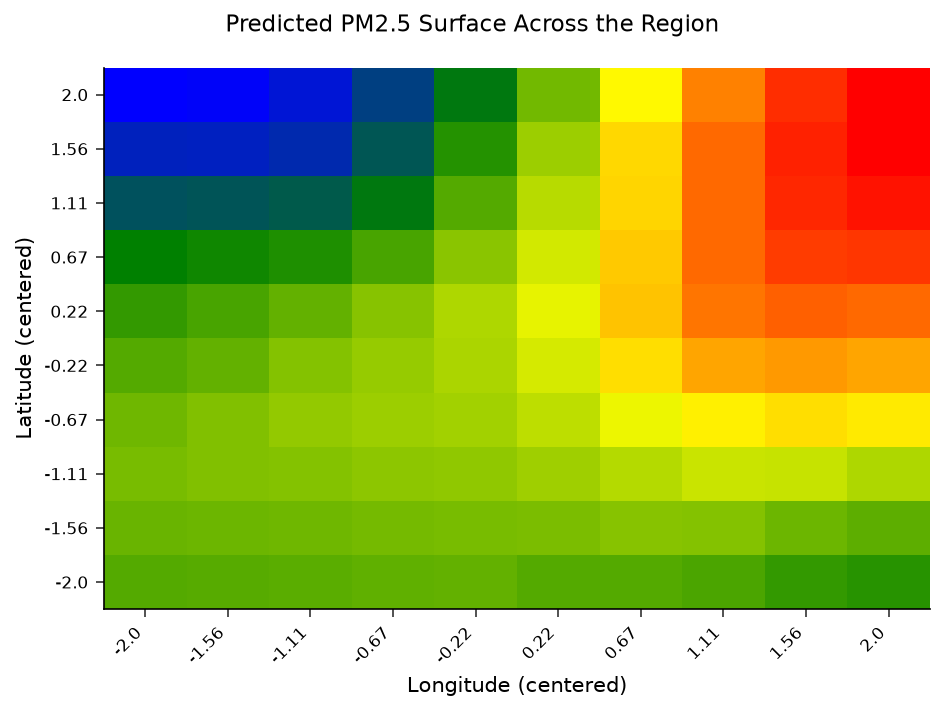

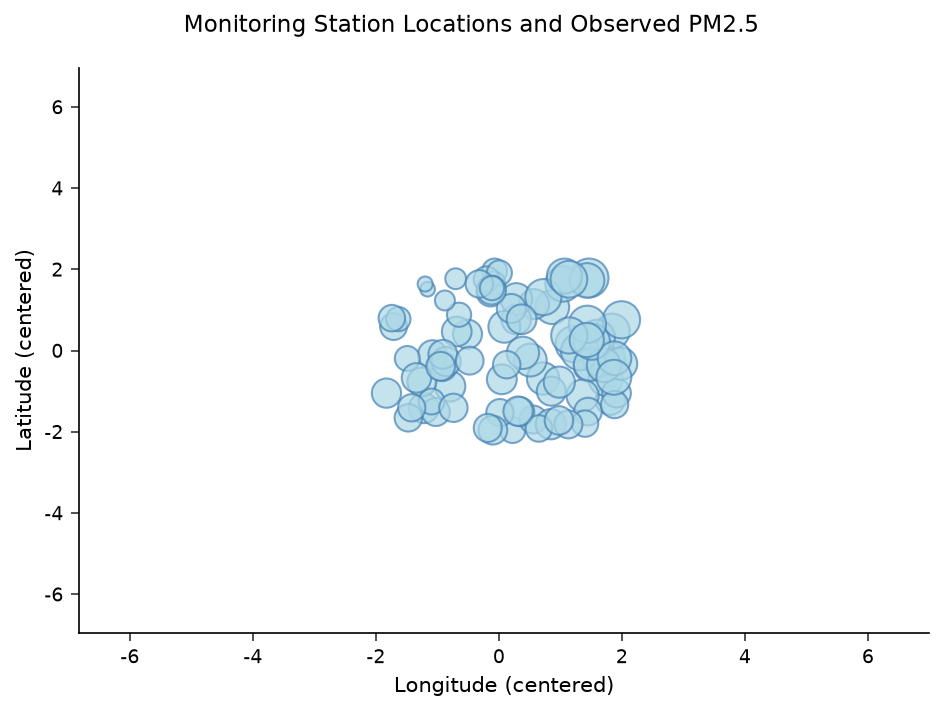

In [6]:
proc sgplot data=gridpred;
   title "Predicted PM2.5 Surface Across the Region";
   heatmapparm x=lon y=lat colorresponse=p_pm25 /
               colormodel=(blue green yellow red);
   xaxis label="Longitude (centered)";
   yaxis label="Latitude (centered)";
run;

proc sgplot data=monitors;
   title "Monitoring Station Locations and Observed PM2.5";
   bubble x=lon y=lat size=pm25 / transparency=0.3;
   xaxis label="Longitude (centered)";
   yaxis label="Latitude (centered)";
run;

## Step 7 — Show where the estimate is uncertain

Sorting the fitted stations by the width of their confidence interval highlights the locations where the surface is least certain — typically the edges of the network or sparsely monitored areas. These are exactly the places an agency would target for a new monitor.

In [7]:
data ci_width;
   set fitted;
   width = uclm_pm25 - lclm_pm25;
run;

proc sort data=ci_width;
   by descending width;
run;

proc print data=ci_width(obs=8) noobs;
   title "Stations with the Widest 95% Confidence Intervals";
   var site lon lat pm25 p_pm25 lclm_pm25 uclm_pm25 width;
run;

                                   Stations with the Widest 95% Confidence Intervals                                    

SITE            LON            LAT           PM25         P_PM25      LCLM_PM25      UCLM_PM25         WIDTH
  42  -1.8277947353   -1.046191541   35.416227386  33.2928474368  29.3455493971  37.2401454766  7.8945960795
  71   1.9931511763   0.7593642827   52.385302799  52.1975332501  48.4372788087  55.9577876915  7.5205088828
  26  -1.4720433236  -1.6544771326  32.1401728815  32.9399290197  29.3393544275  36.5405036119  7.2011491844
  51  -1.1983671806   1.6402450753  15.0904481602  17.6660202206  14.2258110437  21.1062293975  6.8804183537
  47   1.4651608541   1.7883001605  56.6552137381  51.9856069467  48.6964740231  55.2747398703  6.5782658472
  78  -1.7404872001   0.7997823567  30.4642687495  27.1071347803  23.8516084871  30.3626610734  6.5110525863
   7  -1.7124569028   0.5932402628  31.0359523945  28.3076089832  25.0653698748  31.5498480916  6.4844782169
   9  

NOTE: DATA ci_width


NOTE: Read 90 rows from fitted.
NOTE: Wrote ci_width (90 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=ci_width

NOTE: Read 90 rows from ci_width.
NOTE: Wrote ci_width (90 rows, 11 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=ci_width

NOTE: PROC PRINT completed: 8 observations printed, 8 variables


## Interpreting the results

**What the Fit Statistics tell us.** The procedure reports the smoothing parameter it selected, summarized in a single Fit Statistics block: the **Effective DF** measures how many parameters the surface effectively spends, the **RSS** measures how closely it tracks the training stations, and **GCV** trades these off. As the smoothing parameter grows the surface gets smoother — Effective DF falls and RSS rises — so the GCV-minimizing value is the data-driven choice the procedure adopts, sparing the analyst from hand-tuning smoothness. Both the explicit grid search (Step 3) and the automatic optimizer (Step 4) settle on the same point of the smoothness scale — **log10(n*lambda) = -2.5**, Effective DF 20.62, GCV 11.350 — so the candidate list and the unconstrained search agree, a reassuring sign that the optimum is well-identified rather than an artifact of the search range.

**The partial-spline structure.** By placing `elev` outside the parentheses we estimated a single linear elevation coefficient while letting the spatial pattern bend freely. This is more interpretable and more data-efficient than smoothing in all three dimensions, and it matches the physical reality that elevation has a roughly monotone effect on concentration.

**The surface and its uncertainty.** The scored grid (`gridpred`) is a ready-to-map estimate of PM2.5 across the region, while `LCLM_pm25`/`UCLM_pm25` quantify how much to trust each location. On the 90 training stations the spline is essentially unbiased (mean residual 0.000, residual standard deviation 2.61) and its predictions track the observed range (fitted 17.67–52.20 against observed 14.77–56.66). The widest 95% intervals — roughly 6.4 to 7.9 µg/m³ across, led by sites 42, 71, and 26 — all sit near the boundary of the monitoring network (|lon| or |lat| close to 2), a concrete, defensible argument for where the agency should deploy its next station.

**Why this matters for the public sector.** Thin-plate splines let a regulator publish a smooth, statistically principled exposure surface from a handful of monitors, attach honest uncertainty bands, and prioritize limited budget for new sensors — all without imposing an arbitrary parametric form on the pollution field.